#Zero Coverage Prediction in Immunization Program

Dataset contains information about immunization sessions planning, execution, vaccination coverage, and location details



**Probleam Statement :** Predict zero coverage sessions where no beneficiaries are vaccinated despite sessions being conducted.

Zero Coverage (1 = zero vaccination, 0 = normal)

#Import Libraries

In [1128]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

# Load Data

In [1129]:
df=pd.read_csv('/content/Coverage.csv')

# Data Cleaning

In [1130]:
df.shape

(188714, 52)

####Remove unwanted columns

In [1131]:
df.drop(['State','Health Block Name','Sub Center Name','Health ULB Name','LGD Block Name','LGD ULB Name'], axis=1, inplace=True)


####Remove unwanted row

Here in our dataset there are rows where session type is delivery point and on delivery point we are not supposed to plann any session. so remove these rows from dataset

* Rows where the session type is labeled as “delivery point” were identified as irrelevant for analysis, since no sessions are planned at delivery points. Therefore, these rows were removed from the dataset to ensure that the analysis only includes valid and meaningful session data.

In [1132]:
df.drop(df[df["Type"] == "Delivery Point"].index, inplace=True)

In [1133]:
df.shape

(184301, 46)

#Basic Data Check

In [1134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184301 entries, 0 to 188700
Data columns (total 46 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   District                                    184301 non-null  object 
 1   Sub District                                184301 non-null  object 
 2   Health Facility Name                        184301 non-null  object 
 3   Session Site Name                           184301 non-null  object 
 4   Type                                        184301 non-null  object 
 5   Session Planned                             184301 non-null  float64
 6   Session Held                                184301 non-null  float64
 7   Number of Pregnant Women vaccinated         184301 non-null  int64  
 8   Number of Infants (0-1 year) vaccinated     184301 non-null  int64  
 9   Number of Children (>1 year) vaccinated     184301 non-null  int64  
 10  N

In [1135]:
df.describe()

,Session Planned,Session Held,Number of Pregnant Women vaccinated,Number of Infants (0-1 year) vaccinated,Number of Children (>1 year) vaccinated,Number of Adolescents vaccinated,Number of Women vaccinated with Td 1,Number of Women vaccinated with Td 2,Number of Women vaccinated with Td-Booster,Number of Adolescents vaccinated with td10,...,Children vaccinated with DPT 1,Children vaccinated with DPT 2,Children vaccinated with DPT 3,Children vaccinated with OPV-Booster,Children vaccinated with MR-2,Children vaccinated with DPT Booster 1,Children vaccinated with JE-2,Children vaccinated with MMR,Children vaccinated with Typhoid,Children vaccinated with DPT Booster 2
count,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,...,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.000000,184301.00000,184301.00000,184301.0,184301.000000
mean,1.350769,1.101714,0.859285,4.713556,1.284833,0.040233,0.446796,0.318148,0.094351,0.034124,...,0.127227,0.026451,0.004248,0.843962,0.852329,0.935003,0.18077,0.06988,0.0,0.320508
std,1.476116,1.358136,3.791514,13.004941,3.188819,1.433149,2.169281,1.480007,0.687397,1.346607,...,0.830714,0.250123,0.085067,2.188029,2.195407,2.303710,0.91830,0.56592,0.0,1.178450
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,0.000000
50%,1.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,0.000000
75%,1.000000,1.000000,1.000000,6.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,0.00000,0.0,0.000000
max,35.000000,32.000000,322.000000,819.000000,214.000000,344.000000,242.000000,141.000000,85.000000,344.000000,...,100.000000,20.000000,10.000000,167.000000,167.000000,178.000000,61.00000,28.00000,0.0,86.000000


#Check Null Value in he dataset

* there is no null value found in the dataset

In [1136]:
df.isnull().sum()

,0
District,0
Sub District,0
Health Facility Name,0
Session Site Name,0
Type,0
Session Planned,0
Session Held,0
Number of Pregnant Women vaccinated,0
Number of Infants (0-1 year) vaccinated,0
Number of Children (>1 year) vaccinated,0


#Check Duplicate Value in the dataset

* There are 484 duplicate rows found in the dataset

In [1137]:
df.duplicated().sum()

np.int64(484)

In [1138]:
#Delete Duplicate rows

In [1139]:
df.drop_duplicates(inplace=True)

In [1140]:
df.shape

(183817, 46)

#Split data into categorical and Numerical Column

In [1141]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(exclude=['object']).columns

In [1142]:
categorical_columns

Index(['District', 'Sub District', 'Health Facility Name', 'Session Site Name',
       'Type'],
      dtype='object')

In [1143]:
numerical_columns

Index(['Session Planned', 'Session Held',
       'Number of Pregnant Women vaccinated',
       'Number of Infants (0-1 year) vaccinated',
       'Number of Children (>1 year) vaccinated',
       'Number of Adolescents vaccinated',
       'Number of Women vaccinated with Td 1',
       'Number of Women vaccinated with Td 2',
       'Number of Women vaccinated with Td-Booster',
       'Number of Adolescents vaccinated with td10',
       'Number of Adolescents vaccinated with td16',
       'Children vaccinated with BCG', 'Children vaccinated with Hep B',
       'Children vaccinated with OPV-0', 'Children vaccinated with OPV-1',
       'Children vaccinated with RVV1', 'Children vaccinated with fIPV-1',
       'Children vaccinated with PCV-1', 'Children vaccinated with Penta-1',
       'Children vaccinated with OPV-2', 'Children vaccinated with RVV2',
       'Children vaccinated with Penta-2', 'Children vaccinated with OPV-3',
       'Children vaccinated with RVV3', 'Children vaccinated with

#Feature Engineering

##The total number of beneficiaries vaccinated was calculated by summing the following columns:
* Number of Pregnant Women vaccinated
* Number of Infants (0–1 year) vaccinated
* Number of Children (>1 year) vaccinated
* Number of Adolescents vaccinated.

This was then used to identify session sites where the total number of beneficiaries vaccinated is zero, enabling detection of inactive or non-performing sessions.

In [1144]:
#Total Vaccinated
df['Total Vaccinated']=df['Number of Pregnant Women vaccinated']+df['Number of Infants (0-1 year) vaccinated']+df['Number of Children (>1 year) vaccinated']+df['Number of Adolescents vaccinated']

##Session Efficiency :
It was computed as the percentage of sessions successfully conducted out of the total sessions planned, using the formula: (Session Held / Session Planned) × 100.

This helps to assess the effectiveness of session execution and identifies gaps between planned and actual sessions conducted.

In [1145]:
# Session efficiency
df['Session Efficiency'] = df['Session Held'] / (df['Session Planned'] ) * 100

#Avg Vaccinated

In [1146]:
df['Avg Vaccinated']=df['Total Vaccinated']/df['Session Held']

##Target Variable :
 A target variable named Zero_Coverage was created to identify sessions where no beneficiaries were vaccinated despite sessions being conducted.

 It is defined such that if Number of Session Held is greater than zero and Total Vaccinated is zero, the value is assigned as 1 (indicating zero coverage); otherwise, it is assigned as 0. This variable helps in detecting underperforming sessions for further analysis.

In [1147]:
# Create Target Variable
df['Zero_Coverage'] = np.where(
    (df['Session Held'] > 0) & (df['Total Vaccinated'] == 0),
    1,
    0
)

In [1148]:
#Zero_Coverage_List=df[df['Zero_Coverage']==1]


###Target Distribution

Here We can see there are total  29384 session sites where session held bue no beneficiaries vaccinated.

In [1149]:
print("\nTarget Distribution:\n", df['Zero_Coverage'].value_counts())


Target Distribution:
 Zero_Coverage
0    154433
1     29384
Name: count, dtype: int64


#Outlier

In [1150]:
df.shape

(183817, 50)

In [1151]:
for col in numerical_columns:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR=Q3-Q1
  lower_limit=Q1-5*IQR
  upper_limit=Q3+5*IQR

  df=df[(df[col]>=lower_limit) & (df[col]<=upper_limit)]

In [1152]:
df.shape

(54513, 50)

#Univariate/Bivariate analysis of the features

###The correlation analysis indicates that none of the independent variables show a strong linear relationship with the target variable Zero_Coverage. Most features exhibit very low correlation values (close to 0), suggesting weak or negligible direct influence

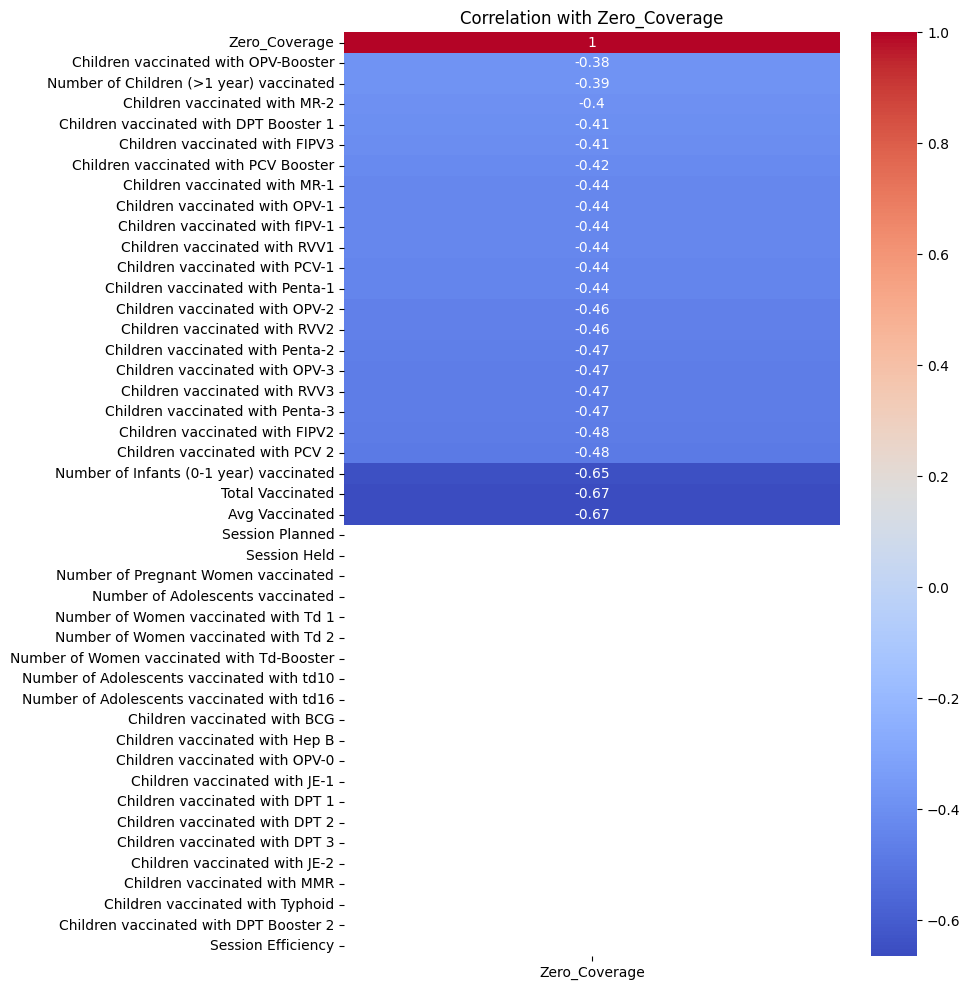

In [1153]:
import matplotlib.pyplot as plt
num_df=df.select_dtypes(exclude='object')
plt.figure(figsize=(8,12))
corr = num_df.corr()[['Zero_Coverage']].sort_values(by='Zero_Coverage', ascending=False)
#print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with Zero_Coverage")
plt.show()

##From Below charts Zero coverage cases are significantly lower than non-zero cases.
##Most Session sites have low average vaccination, with a few sites having much higher values.

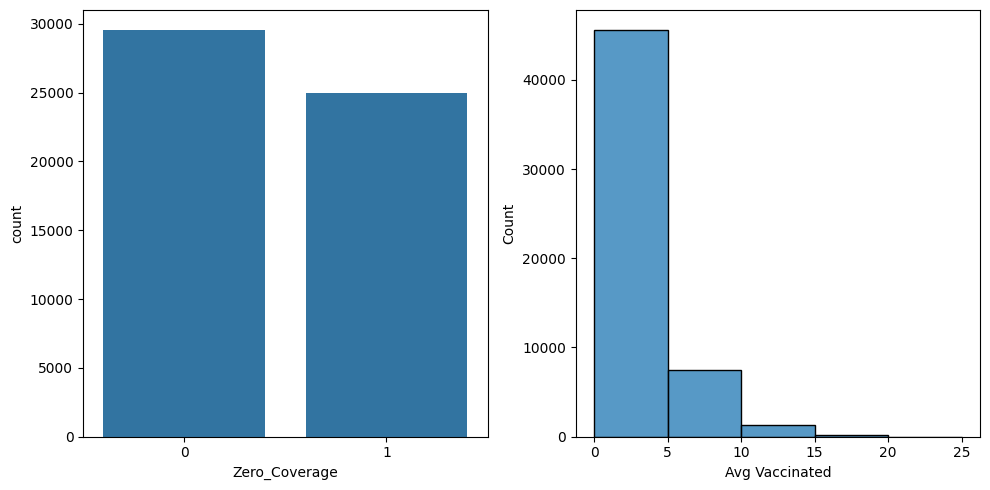

In [1154]:
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported if not already

fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.countplot(x='Zero_Coverage', data=df, ax=axes[0])
sns.histplot(df['Avg Vaccinated'], bins=5, ax=axes[1])
plt.tight_layout() # Add this for better layout
plt.show()

##From the below bar plot, Palghar district has the highest average number of beneficiaries vaccinated, followed by Mumbai and Pune.
##In contrast, districts like Yavatmal and Washim show the lowest vaccination coverage.

<Axes: xlabel='Avg Vaccinated', ylabel='District'>

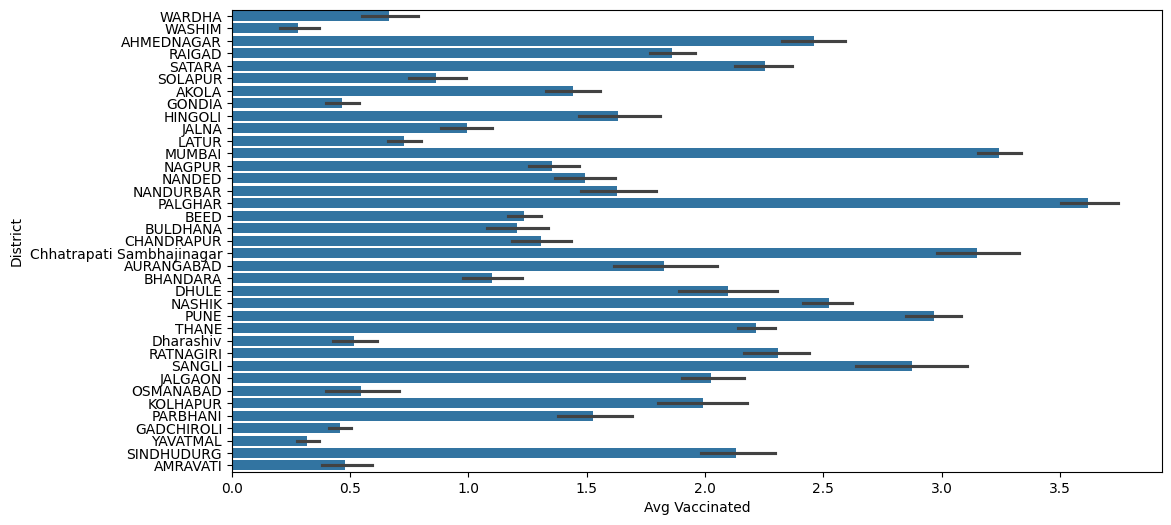

In [1155]:
df_sorted = df.sort_values(by='Avg Vaccinated', ascending=True)
plt.figure(figsize=(12,6))
sns.barplot(x='Avg Vaccinated', y='District', data=df_sorted)


#Convert Categorical Col into Numerical Col

In [1156]:
le_d={}
from sklearn.preprocessing import LabelEncoder

for col in categorical_columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  le_d[col]=le

In [1157]:
le_d

{'District': LabelEncoder(),
 'Sub District': LabelEncoder(),
 'Health Facility Name': LabelEncoder(),
 'Session Site Name': LabelEncoder(),
 'Type': LabelEncoder()}

#Select Feature

Using all columns introduced data leakage because some features like vaccination counts were used to derive the target variable Zero_Coverage. This made the model learn the answer instead of predicting it.

**I selected features that are predictive but not deterministic of the target.**

I selected only relevant features that are available before the outcome occurs and avoided columns that directly or indirectly define the target variable. Including all columns, especially vaccination-related ones, **caused data leakage and led to unrealistic 100% accuracy**. So I carefully chose features that help the model generalize to real-world scenarios.”



In [1158]:
##Changes done
#X = df.drop(['Zero_Coverage', 'Total Vaccinated'], axis=1)

#X = df.drop([
 #   'Zero_Coverage',
  #  'Total Vaccinated',
   # 'Number of Pregnant Women vaccinated',
    #'Number of Infants (0-1 year) vaccinated',
    #'Number of Children (>1 year) vaccinated',
    #'Number of Adolescents vaccinated',
    #'Session Held'
#], axis=1)
#cols_to_drop = [col for col in X.columns if 'vaccinated' in col.lower()]

#X = X.drop(cols_to_drop, axis=1)
X=df[['District','Sub District','Health Facility Name','Session Site Name','Session Planned','Session Efficiency']]

y =df['Zero_Coverage']

#Train-Test Split

In [1159]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [1160]:
X_train.columns

Index(['District', 'Sub District', 'Health Facility Name', 'Session Site Name',
       'Session Planned', 'Session Efficiency'],
      dtype='object')

#Model Training

##Random Forest and Decision Tree were selected for this problem as it is a binary classification task.

In [1161]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

#rf = RandomForestClassifier(
 #   n_estimators=100,
  #  random_state=42,
   # class_weight='balanced'
#)

rf = RandomForestClassifier()
dt = DecisionTreeClassifier()


In [1162]:
rf.fit(X_train , y_train)

RandomForestClassifier()

In [1163]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

#Predictions

Predict y_pred by passing X_test to the model built.



In [1164]:
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

#Evaluation

F1 Score is used to measure model performance by combining both precision and recall into a single value.

It helps in understanding how well the model is identifying zero coverage sessions without making too many mistakes.

This metric is useful when the data is imbalanced.(We have imbalance data - 0=  154433, 1=29384

In [1165]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("F1 Score rf:", f1_score(y_test, rf_pred))
print("F1 Score dt:", f1_score(y_test, dt_pred))
#print("\nClassification Report:\n", classification_report(y_test, y_pred))

F1 Score rf: 0.5735362875993558
F1 Score dt: 0.5458163045816304


####The classification report provides a detailed summary of model performance by displaying precision, recall, F1-score, and support for each class. It helps in evaluating how well the model is performing across different categories, especially in imbalanced datasets.


In [1166]:
print("classification_report rf:\n", classification_report(y_test, rf_pred))
print("-"*20)
print("classification_report dt:\n", classification_report(y_test, dt_pred))



classification_report rf:
               precision    recall  f1-score   support

           0       0.64      0.69      0.66     11769
           1       0.60      0.55      0.57     10037

    accuracy                           0.62     21806
   macro avg       0.62      0.62      0.62     21806
weighted avg       0.62      0.62      0.62     21806

--------------------
classification_report dt:
               precision    recall  f1-score   support

           0       0.63      0.70      0.66     11769
           1       0.59      0.51      0.55     10037

    accuracy                           0.61     21806
   macro avg       0.61      0.60      0.60     21806
weighted avg       0.61      0.61      0.61     21806



##The confusion matrix shows that the model correctly identifies a good number of zero-coverage sessions (5521) and normal sessions (8049), but still misclassifies several cases, especially missing 4516 zero-coverage sessions. This indicates the model has moderate performance

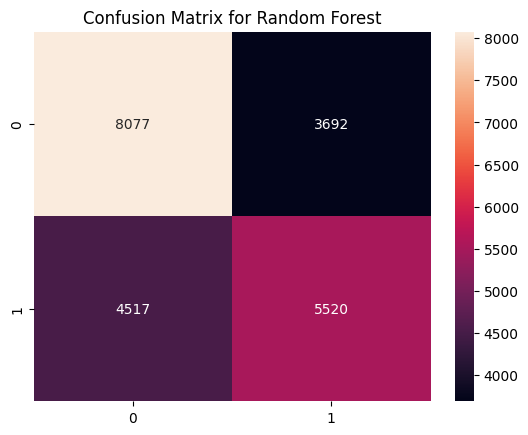

In [1167]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title('Confusion Matrix for Random Forest')
plt.show()

# Feature Importance

In [1168]:
# Get feature names after
feature_names = X_train.columns

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

In [1169]:
print("\nTop Features:\n", importances)


Top Features:
 Session Site Name       0.542748
Health Facility Name    0.222034
District                0.125081
Sub District            0.110137
Session Planned         0.000000
Session Efficiency      0.000000
dtype: float64


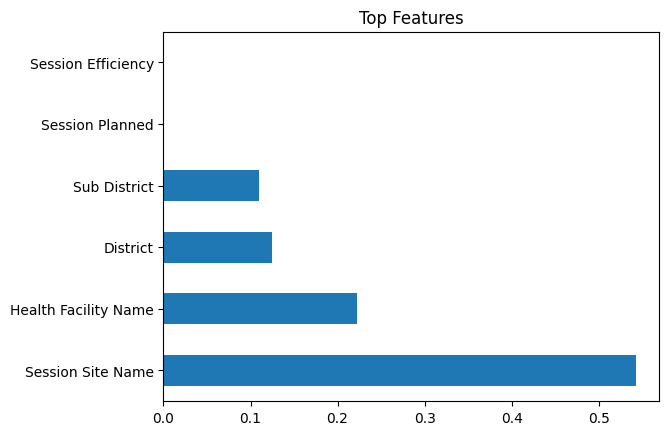

In [1170]:
# Plot feature importance
import matplotlib.pyplot as plt
importances.head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

#What This Model Will Do

It will learn patterns and predict zero coverage sessions where no beneficiaries are vaccinated despite sessions being conducted...

#Testing model on synthetic(dummy) data

* Prior to applying the model on the actual dataset, it was tested on synthetic (dummy) data to confirm the robustness and correctness of the implementation. This preliminary validation step ensured that the model operates without errors.

In [1171]:
df_input = pd.DataFrame([
    {
        'District': 'AHMEDNAGAR',
        'Sub District': 'Akole',
        'Health Facility Name': 'PHC Shendi',
        'Session Site Name': 'Deshmukhwadi AWC (Kelungan)',
        'Session Planned': 1,
        'Session Efficiency':0
    }])

In [1172]:
cols=['District','Sub District','Health Facility Name','Session Site Name']
for i in cols:

  df_input[i] = le_d[i].fit_transform(df_input[i])

In [1173]:
predicted_performance_index = rf.predict(df_input)

In [1174]:
predicted_performance_index

array([0])

In [1175]:
#for i in cols:
 # print(i,le_d[i].inverse_transform(predicted_performance_index))
